In [70]:
# Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# seaborn
import seaborn as sns

In [71]:
sns.set_theme()

# Load dataset
# sample dataset from the seaborn library
# description: https://www.kaggle.com/jsphyg/tipping
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [72]:
# the groups are imbalanced
pd.DataFrame(tips['sex'].value_counts())

,count
sex,
Male,157
Female,87


**Research question**: Do men or women leave higher tips in restaurants?


### Relationship between total bill and tip

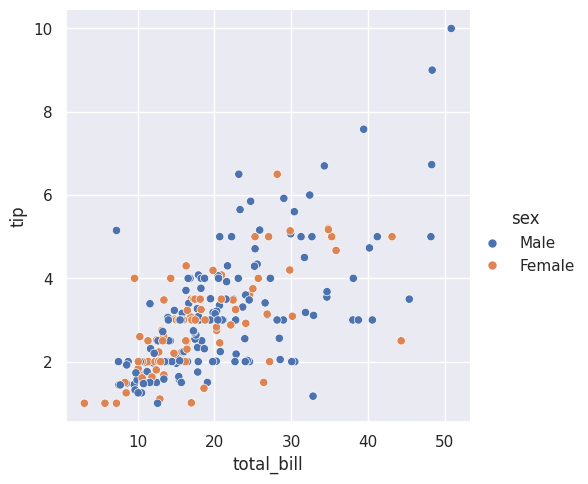

In [73]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="sex")

**Interpetation**:
- tip increases with total bill, which is expected behaviour
- no strong gender-specific pattern is visible
- extreme values (high tips relative to bill) are mostly from male customers

### Tip comparison (boxplot)

<Axes: xlabel='sex', ylabel='tip'>

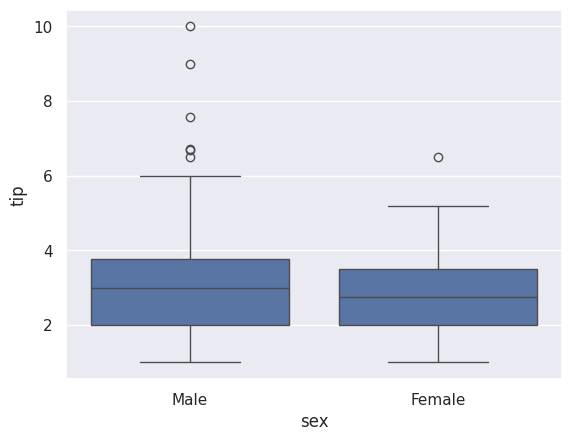

In [74]:
sns.boxplot(x="sex", y="tip", data=tips)

**Interpretation:**
- median tip is similar (approximately 3 USD) for both groups
- men show higher variance in tipping behaviour
- men produce more extreme outliers (very high tips)

### Distribution of tips
- dataset is imbalanced (more male respondents)
- not relevant for this analysis, but shows that we should look differently on data -->

### Normalized metric: tip percentage
Absolute tips are influenced by bill size, so we define `tip_pct` attribute, which express "generosity" (in percents).

In [75]:
tips["tip_pct"] = (tips["tip"] / tips["total_bill"]) * 100
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


### Tip percentage comparison

<Axes: xlabel='sex', ylabel='tip_pct'>

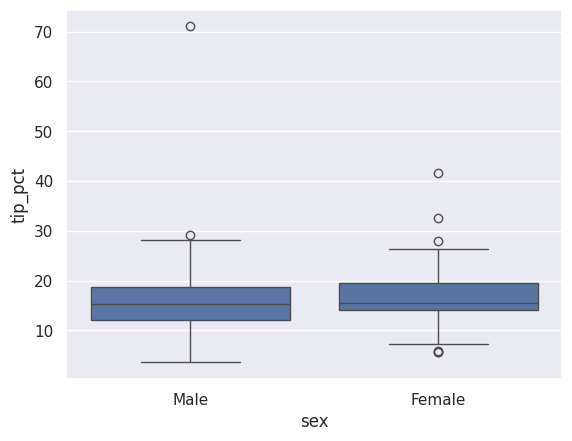

In [76]:
sns.boxplot(data=tips, x="sex", y="tip_pct")

**Interpretation**
- median values are very similar
- women slightly outperform men in relative tipping
- variability is comparable, but men show more extreme values

<Axes: xlabel='sex', ylabel='tip_pct'>

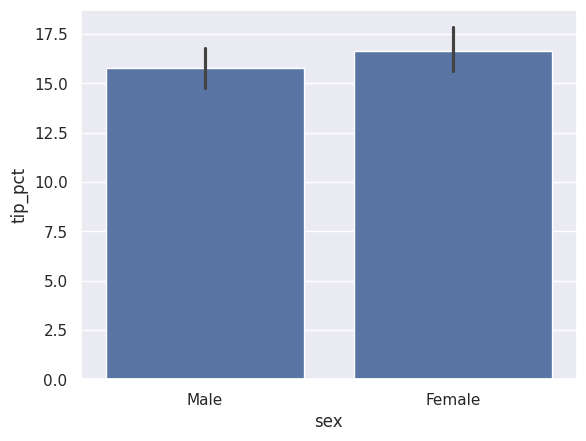

In [77]:
sns.barplot(x="sex", y="tip_pct", data=tips)

**Interpretation**
- difference is minimal (approx. 1%)
- not practically significant

<Axes: xlabel='sex', ylabel='tip_pct'>

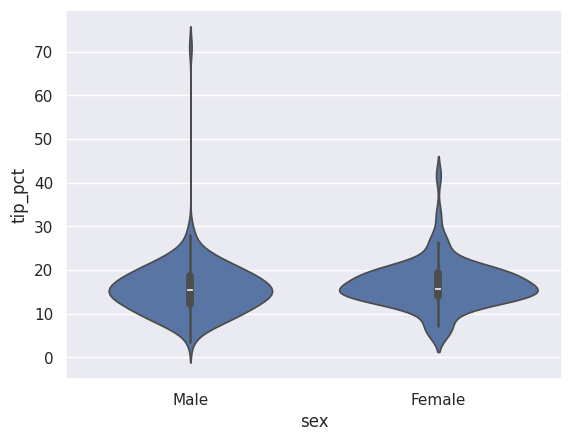

In [78]:
sns.violinplot(x="sex", y="tip_pct", data=tips)

**Interpretation**
- no stronger separation between groups

### Day-of-week analysis (relative)

<Axes: xlabel='day', ylabel='tip_pct'>

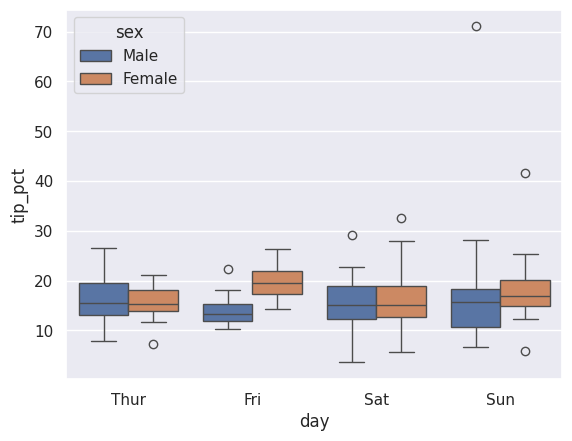

In [79]:
sns.boxplot(x="day", y="tip_pct", hue="sex", data=tips)

**Interpretation**:
- on Friday, women tip noticeably more
- Sunday also shows a slight more tipping from women
- other days are balanced

### Absolute tips by day

<Axes: xlabel='day', ylabel='tip'>

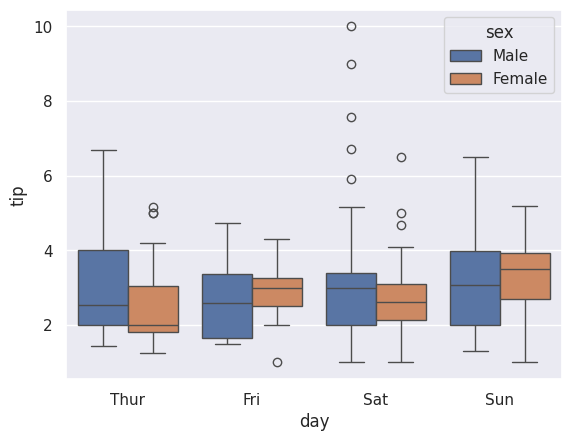

In [80]:
sns.boxplot(x="day", y="tip", hue="sex", data=tips)

**Interpretation:**
- patterns are similar to percentage analysis (except Monday)
- Friday difference becomes less significant
- Monday has completelly opposite outcome

### Smoker vs non-smoker analysis

<Axes: xlabel='smoker', ylabel='tip_pct'>

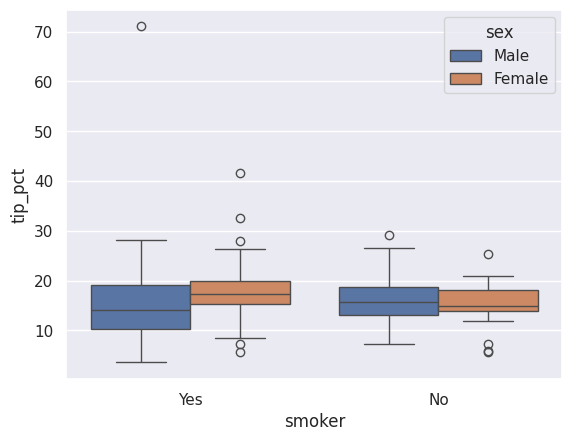

In [81]:
sns.boxplot(x="smoker", y="tip_pct", hue="sex", data=tips)

<Axes: xlabel='smoker', ylabel='tip_pct'>

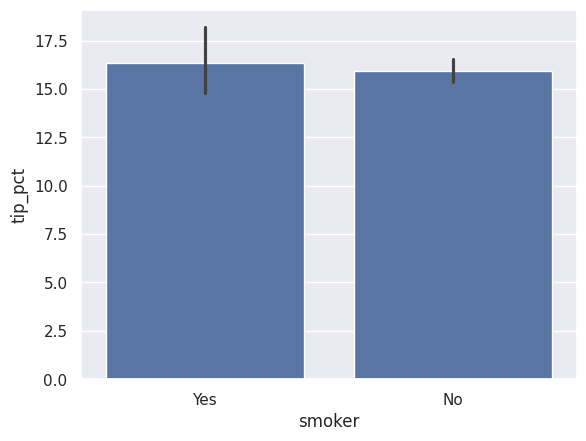

In [82]:
sns.barplot(x="smoker", y="tip_pct", data=tips)

**Interpretation**:
- smokers tend to tip slightly more
- women among non-smokers tip slighly less
- differences are small (approx 1%)

### Time of day analysis

<Axes: xlabel='time', ylabel='tip_pct'>

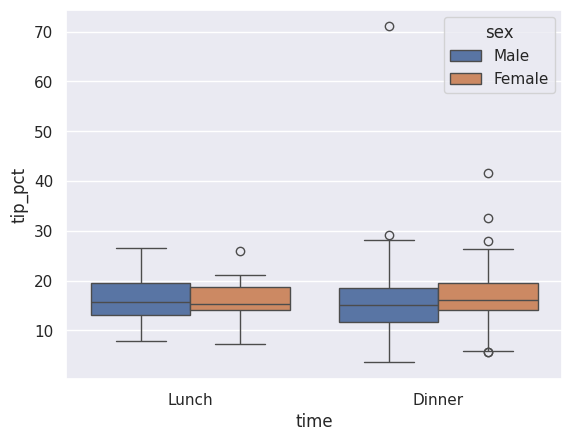

In [83]:
sns.boxplot(x="time", y="tip_pct", hue="sex", data=tips)

**Interpretation**
- women tip slightly more at dinner than men
- men tip slightly more at lunch than women

### Conclusion
**Gender is not a strong predictor of tipping behaviour in this dataset**

Differences exist, but they are small (~ 1%) and not practically significant compared to otehr factors like bill size or context (day, smoking status, time).